In [1]:
import numpy as np
import scipy
import scanpy as sc
import scvelo as scv
import cellrank as cr


sc.set_figure_params(dpi=120, frameon=False)
scv.settings.verbosity = 3


In [2]:
import anndata
print(anndata.__version__)

0.11.4


In [3]:
import h5py

INP = "GSE280305_velocity_full.server.h5ad"
OUT = "GSE280305_velocity_full.server.patched.h5ad"

# copy file first (preserve original)
import shutil
shutil.copyfile(INP, OUT)

with h5py.File(OUT, "r+") as f:
    # delete the problematic scalar if present
    path = "uns/neighbors/params/n_pcs"
    if path in f:
        del f[path]
        print("deleted:", path)

    # sometimes other params cause same issue; safe to drop the whole params group
    # (CellRank/Scanpy can recompute neighbors later)
    grp = "uns/neighbors/params"
    if grp in f:
        # optional: wipe all params to avoid further "null" landmines
        for k in list(f[grp].keys()):
            try:
                del f[f"{grp}/{k}"]
                print("deleted:", f"{grp}/{k}")
            except Exception as e:
                print("skip", k, e)

print("patched file:", OUT)


deleted: uns/neighbors/params/n_pcs
deleted: uns/neighbors/params/method
deleted: uns/neighbors/params/metric
deleted: uns/neighbors/params/n_neighbors
deleted: uns/neighbors/params/use_rep
patched file: GSE280305_velocity_full.server.patched.h5ad


In [4]:
VEL_IN = "GSE280305_velocity_full.server.patched.h5ad"   # adjust path if needed
adata_v = sc.read_h5ad(VEL_IN)
adata_v


AnnData object with n_obs × n_vars = 31605 × 1500
    obs: 'timepoint', 'sample', 'gsm', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'velocity_self_transition'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes'
    uns: 'neighbors', 'pca', 'timepoint_colors', 'velocity_graph', 'velocity_graph_neg', 'velocity_params'
    obsm: 'X_pca', 'X_umap', 'X_umap_raw', 'X_umap_scanorama', 'velocity_umap'
    varm: 'PCs'
    layers: 'Ms', 'Mu', 'ambiguous', 'matrix', 'spliced', 'unspliced', 'variance_velocity', 'velocity'
    obsp: 'connectivities', 'distances'

In [5]:
print("layers:", list(adata_v.layers.keys())[:10])
print("has velocity:", "velocity" in adata_v.layers)
print("has velocity_graph:", "velocity_graph" in adata_v.uns)
print("timepoints:", adata_v.obs["timepoint"].value_counts().to_dict())


layers: ['Ms', 'Mu', 'ambiguous', 'matrix', 'spliced', 'unspliced', 'variance_velocity', 'velocity']
has velocity: True
has velocity_graph: True
timepoints: {'D8': 13149, 'D21': 8329, 'D14': 5614, 'D11': 4513}


In [6]:
from cellrank.kernels import VelocityKernel, ConnectivityKernel

vk = VelocityKernel(adata_v).compute_transition_matrix()
ck = ConnectivityKernel(adata_v).compute_transition_matrix()

kernel = 0.8 * vk + 0.2 * ck
kernel


  0%|          | 0/31605 [00:00<?, ?cell/s]

  0%|          | 0/31605 [00:00<?, ?cell/s]

(0.8 * VelocityKernel[n=31605, model='deterministic', similarity='correlation', softmax_scale=np.float64(8.294)] + 0.2 * ConnectivityKernel[n=31605, dnorm=True, key='connectivities'])

In [7]:
g = cr.estimators.GPCCA(kernel)

# core decomposition
g.compute_schur(n_components=20)
g.compute_macrostates(n_states=6)

# terminal states + lineages / fate probs (version-flexible)
if hasattr(g, "predict_terminal_states"):
    g.predict_terminal_states()
elif hasattr(g, "compute_terminal_states"):
    g.compute_terminal_states()
else:
    raise RuntimeError("No terminal-state method found on this GPCCA object. Print dir(g) outputs.")

# fate probabilities / lineages
if hasattr(g, "compute_fate_probabilities"):
    g.compute_fate_probabilities()
elif hasattr(g, "compute_lineages"):
    g.compute_lineages()
else:
    raise RuntimeError("No fate/lineage method found. Print dir(g) outputs.")

  0%|          | 0/6 [00:00<?, ?/s]

/user/ifrec/liuyuchen/mambaforge/envs/cellrank310/lib/python3.10/site-packages/scvelo/plotting/scatter.py:656: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(
/user/ifrec/liuyuchen/mambaforge/envs/cellrank310/lib/python3.10/site-packages/scvelo/plotting/scatter.py:694: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
/user/ifrec/liuyuchen/mambaforge/envs/cellrank310/lib/python3.10/site-packages/scvelo/plotting/utils.py:1396: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x, y, s=bg_size, marker=".", c=bg_color, zorder=zord - 2, **kwargs)
/user/ifrec/liuyuchen/mambaforge/envs/cellrank310/lib/python3.10/site-packages/scvelo/plotting/utils.py:1397: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x, y, s=gp_size, marker=".", c=gp_color, zorder=zord - 1, **kwargs)


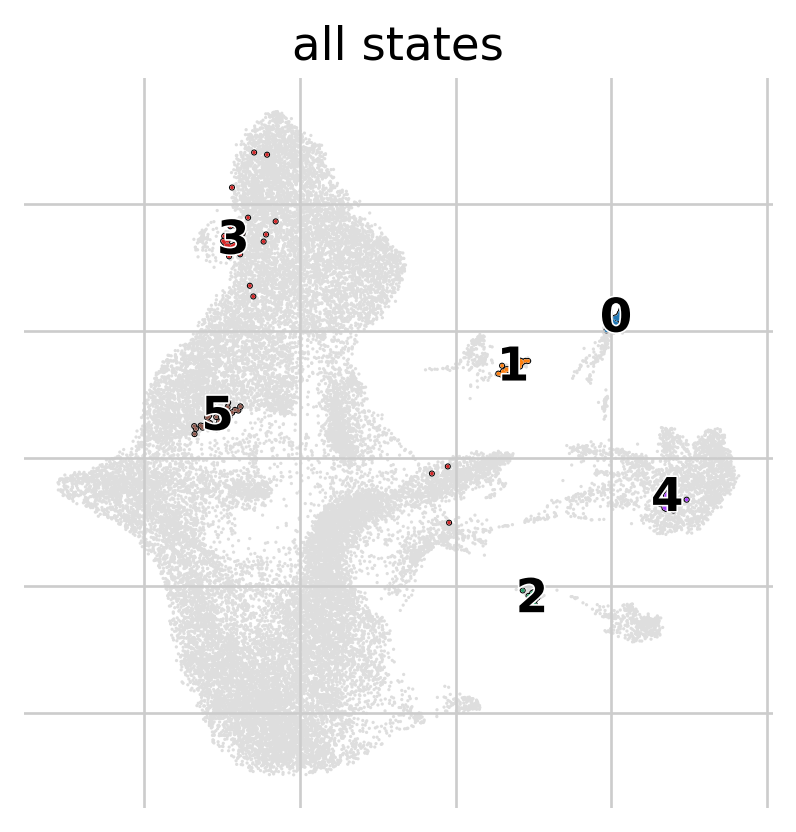

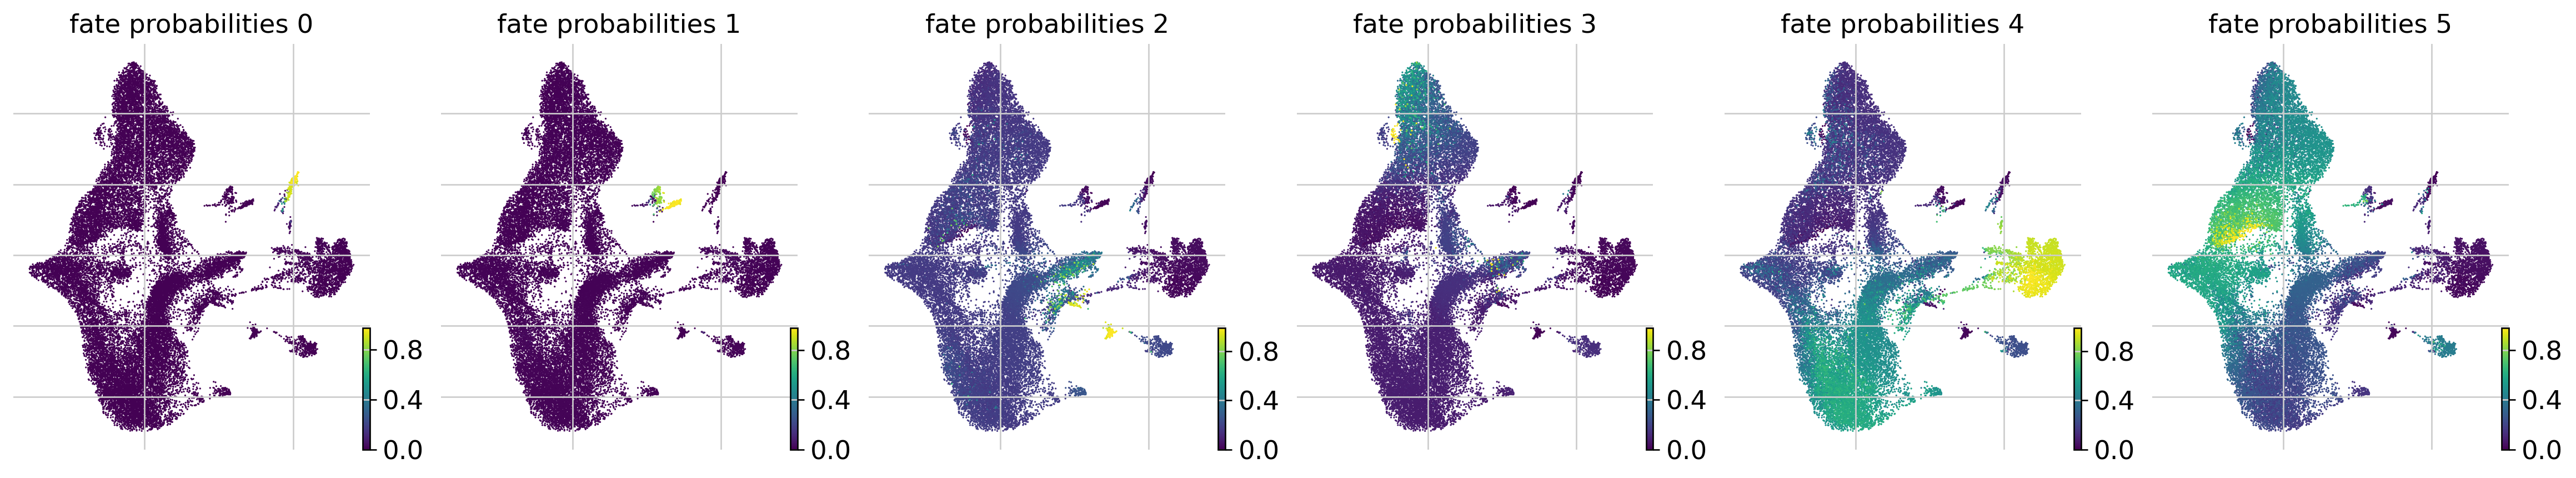

In [8]:
# macrostates
if hasattr(g, "plot_macrostates"):
    g.plot_macrostates(which="all", basis="umap")

# terminal states
if hasattr(g, "plot_terminal_states"):
    g.plot_terminal_states(basis="umap")

# fate probabilities
if hasattr(g, "plot_fate_probabilities"):
    g.plot_fate_probabilities(basis="umap", same_plot=False)


In [9]:
print("obs cols w/ terminal:", [c for c in adata_v.obs.columns if "terminal" in c.lower()])
print("obs cols w/ macro:", [c for c in adata_v.obs.columns if "macro" in c.lower()])
print("obsm lineage keys:", [k for k in adata_v.obsm.keys() if "lineage" in k.lower() or "fate" in k.lower()])


obs cols w/ terminal: []
obs cols w/ macro: ['macrostates_fwd']
obsm lineage keys: ['lineages_fwd']


In [10]:
fp = g.fate_probabilities
print(type(fp))
print("lineage names:", getattr(fp, "names", None))
print("shape:", getattr(fp, "shape", None))


<class 'cellrank._utils._lineage.Lineage'>
lineage names: ['0' '1' '2' '3' '4' '5']
shape: (31605, 6)


In [11]:

import pandas as pd
fp = g.fate_probabilities

# 1) Preferred: Lineage exposes .X (often a pandas DataFrame or ndarray)
if hasattr(fp, "X"):
    X = fp.X
    if isinstance(X, pd.DataFrame):
        mat = X.to_numpy()
        names = X.columns.astype(str).tolist()
    else:
        mat = np.asarray(X)
        names = list(getattr(fp, "names", [f"lin_{i}" for i in range(mat.shape[1])]))

# 2) Alternative: Lineage exposes .to_df()
elif hasattr(fp, "to_df"):
    df = fp.to_df()
    mat = df.to_numpy()
    names = df.columns.astype(str).tolist()

# 3) Fallback: try numpy conversion directly
else:
    mat = np.asarray(fp)
    names = list(getattr(fp, "names", [f"lin_{i}" for i in range(mat.shape[1])]))

adata_v.obsm["lineages_gpcca"] = mat.astype("float32")
adata_v.uns["lineages_gpcca_names"] = names
print("saved fate probs:", adata_v.obsm["lineages_gpcca"].shape, "names:", len(names))

saved fate probs: (31605, 6) names: 6


In [12]:
# common keys across versions
for key in ["terminal_states", "term_states", "terminal_state", "terminal"]:
    hits = [c for c in adata_v.obs.columns if key in c.lower()]
    if hits:
        print("terminal columns:", hits)


terminal columns: ['term_states_fwd', 'term_states_fwd_probs']


In [13]:
adata_v.write("GSE280305_pathC_gpcca.h5ad")
